In [13]:
from importnb import imports
with imports("ipynb"):
    import functions  # type: ignore

In [14]:
# =============================================================================
#
# Pronositco usando un stacked MLP
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#


df_orig = functions.load_data()
df_orig.head()

,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [15]:
#
# Construcción de la matriz de regresores
#
df_orig = functions.make_lagged_ts(
    df=df_orig,
    p_max=13,
    y_column="yt_true",
    fmt="lagged_{}m",
)
df_orig.head()

,yt_true,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m
date,,,,,,,,,,,,,,
1946-01-01,890,0,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,992,890,0,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,979,992,890,0,0,0,0,0,0,0,0,0,0,0
1946-04-01,959,979,992,890,0,0,0,0,0,0,0,0,0,0
1946-05-01,1110,959,979,992,890,0,0,0,0,0,0,0,0,0


In [16]:
#
# Remoción de los valores faltantes
#
df_dropna = df_orig.dropna()
df_dropna.head()

,yt_true,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m
date,,,,,,,,,,,,,,
1946-01-01,890,0,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,992,890,0,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,979,992,890,0,0,0,0,0,0,0,0,0,0,0
1946-04-01,959,979,992,890,0,0,0,0,0,0,0,0,0,0
1946-05-01,1110,959,979,992,890,0,0,0,0,0,0,0,0,0


In [17]:
#
# División de los datos en entrenamiento y prueba
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_dropna,
    x_columns=[f"lagged_{i}m" for i in range(1, 13)],
    y_column="yt_true",
)
X_complete.head()

,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m
date,,,,,,,,,,,,
1946-01-01,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,890,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,992,890,0,0,0,0,0,0,0,0,0,0
1946-04-01,979,992,890,0,0,0,0,0,0,0,0,0
1946-05-01,959,979,992,890,0,0,0,0,0,0,0,0


In [18]:
#
# Pronostico usando una red neuronal tipo MLP
#
from sklearn.pipeline import Pipeline  #  type: ignore
from sklearn.preprocessing import MinMaxScaler  #  type: ignore
from sklearn.compose import TransformedTargetRegressor  #  type: ignore
from sklearn.neural_network import MLPRegressor  #  type: ignore


# Crea un pipeline para automatizar la creacion de un modelo
def make_pipeline_from_model(model):
    """Create a pipeline."""
    return Pipeline(
        [
            (
                "scaler",
                MinMaxScaler(),
            ),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=model,
                    transformer=MinMaxScaler(),
                ),
            ),
        ]
    )

In [19]:
#
# Entrenamiento y pronostico del Modelo 0
#
hidden = 8

pipeline_0 = make_pipeline_from_model(
    model=MLPRegressor(
        hidden_layer_sizes=(hidden,),
        activation="logistic",
        learning_rate="adaptive",
        momentum=0.01,
        learning_rate_init=0.2,
        max_iter=10000,
        random_state=123456,
    )
)

pipeline_0.fit(X_train, y_train)

X_train_stacked = X_train.copy()
X_train_stacked["forecast_pipeline_0"] = pipeline_0.predict(X_train)

X_complete_stacked = X_complete.copy()
X_complete_stacked["forecast_pipeline_0"] = pipeline_0.predict(X_complete)

X_complete_stacked

,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,forecast_pipeline_0
date,,,,,,,,,,,,,
1946-01-01,0,0,0,0,0,0,0,0,0,0,0,0,1342.339438
1946-02-01,890,0,0,0,0,0,0,0,0,0,0,0,1478.018190
1946-03-01,992,890,0,0,0,0,0,0,0,0,0,0,1418.970172
1946-04-01,979,992,890,0,0,0,0,0,0,0,0,0,1365.377708
1946-05-01,959,979,992,890,0,0,0,0,0,0,0,0,1260.042656
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966-08-01,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,6345,6481,5479.799595
1966-09-01,6905,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,6345,5700.374896
1966-10-01,5504,6905,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,5062.329036


In [20]:
#
# Entrenamiento y pronostico del Modelo 1
#
hidden = 8

pipeline_1 = make_pipeline_from_model(
    model=MLPRegressor(
        hidden_layer_sizes=(hidden,),
        activation="logistic",
        learning_rate="adaptive",
        momentum=0.01,
        learning_rate_init=0.2,
        max_iter=10000,
        random_state=12345,
    )
)

pipeline_1.fit(X_train_stacked, y_train)


df_dropna[f"yt_pred_stacked_mlp"] = pipeline_1.predict(X_complete_stacked)

df_dropna

,yt_true,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m,yt_pred_stacked_mlp
date,,,,,,,,,,,,,,,
1946-01-01,890,0,0,0,0,0,0,0,0,0,0,0,0,0,912.326566
1946-02-01,992,890,0,0,0,0,0,0,0,0,0,0,0,0,1079.174785
1946-03-01,979,992,890,0,0,0,0,0,0,0,0,0,0,0,978.874110
1946-04-01,959,979,992,890,0,0,0,0,0,0,0,0,0,0,856.194963
1946-05-01,1110,959,979,992,890,0,0,0,0,0,0,0,0,0,743.189347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966-08-01,6905,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,6345,6481,4594,4639.182194
1966-09-01,5504,6905,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,6345,6481,4843.945442
1966-10-01,5457,5504,6905,5080,4798,4858,4734,4251,4140,4158,4573,4824,5142,6345,4472.966285


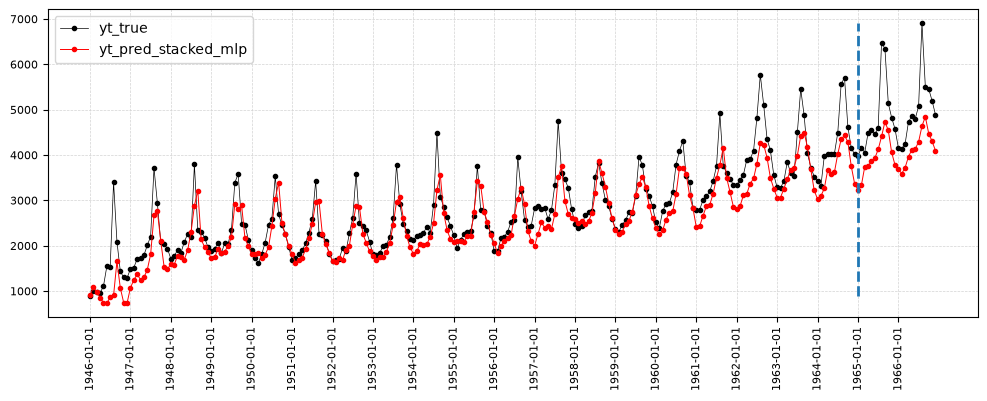

In [21]:
#
# Gráfica de los pronósticos
#
df_orig.loc[df_dropna.index, f"yt_pred_stacked_mlp"] = df_dropna[f"yt_pred_stacked_mlp"]

functions.plot_time_series(df=df_orig, yt_col="yt_true")

In [22]:
#
# Almacenamiento de los resultados
#
functions.save_forecasts(df_orig)

In [23]:
#
# Métricas de error
#
metrics = functions.compute_evaluation_metrics(df_orig.dropna())
functions.save_metrics(metrics)
metrics

,Metrics,yt_pred_stacked_mlp
0,MSE Train,201300.61
1,MSE Test,929413.63
2,MAE Train,322.55
3,MAE Test,844.48
